# Trade-off Precision-Recall

## Motivación

Al hacer una predicción con YOLO (por ejemplo, al contar capítulos en el video del dron en `03_Conteo_Video_Dron.ipynb`), es necesario indicar explícitamente un **umbral de confianza** (`conf`): toda detección por debajo de ese valor se descarta y no se cuenta. Este parámetro determina directamente el equilibrio entre falsos positivos (contar algo que no es un capítulo) y falsos negativos (no detectar un capítulo real), y por lo tanto **influye de forma directa en el resultado del conteo**.

Hasta ahora, ese umbral se había fijado en `conf=0.5` a partir de una inspección visual sobre un conjunto reducido de imágenes representativas del set de validación — un criterio razonable como primera aproximación, pero subjetivo y difícil de reproducir o justificar de forma cuantitativa.

Este notebook busca reemplazar esa elección por un análisis sistemático: barremos un rango de valores de `conf`, medimos precision y recall agregados sobre **todo** el set de validación para cada uno, y elegimos el punto de operación con un criterio explícito y reproducible.

## ¿Por qué no usar directamente las métricas que reporta el entrenamiento?

Durante el entrenamiento, Ultralytics reporta valores de `precision`, `recall` y `mAP50` (visibles en las curvas de W&B) que podrían parecer un punto de partida natural. Sin embargo, esos valores **no corresponden a un umbral de confianza fijo**. Según el código fuente de la librería (`ultralytics/utils/metrics.py`, función `ap_per_class`), el procedimiento es el siguiente:

1. Para cada clase, se construyen curvas de precisión, recall y F1 a lo largo de 1000 valores de umbral de confianza interpolados sobre la curva precision-recall.
2. Se promedian las curvas de F1 entre clases y se aplica un suavizado (convolución).
3. Se reporta como `precision`/`recall` el punto donde esa curva de F1 promedio (suavizada) alcanza su máximo:

```python
i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
p, r, f1 = p_curve[:, i], r_curve[:, i], f1_curve[:, i]  # max-F1 precision, recall, F1 values
```

Es decir, el `recall` que se ve en W&B ya es el recall en el punto de máximo F1 según el criterio interno de la librería — **no** el recall que se obtendría al correr inferencia con `conf=0.25` (su valor por defecto) ni con ningún otro umbral fijo. Esto explica, por ejemplo, que el recall reportado durante el entrenamiento de `yolo11s_sgd-4` (≈0.84) difiera del recall medido explícitamente en `conf=0.25` (0.888, ver barrido más abajo): son dos puntos distintos de la misma curva precision-recall, no una inconsistencia.

## Qué hacemos en este notebook

Replicamos ese mismo espíritu (encontrar el punto de equilibrio entre precision y recall) pero de forma **explícita, transparente y adaptada a nuestro problema**: en lugar de depender del cálculo interno de la librería —pensado para reportar una métrica general durante el entrenamiento—, corremos inferencia real sobre el set de validación en distintos valores de `conf`, medimos precision/recall/F1 agregados, y así podemos:

- verificar en qué punto se ubica el máximo F1 para nuestro modelo final, y
- a partir de ahí, decidir con criterio propio si conviene desplazarse hacia un mayor recall o una mayor precisión, según el costo relativo de falsos positivos y falsos negativos en la tarea de **conteo** de capítulos de girasol.

In [1]:
import os
import glob
import torch
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

%matplotlib inline

MODEL_PATH = "best.pt"
DATASET_PATH = "sunflower_unified"
VAL_IMAGES_DIR = os.path.join(DATASET_PATH, "valid", "images")
VAL_LABELS_DIR = os.path.join(DATASET_PATH, "valid", "labels")

assert os.path.exists(MODEL_PATH), f"No se encontró el modelo: {MODEL_PATH}"
assert os.path.exists(VAL_IMAGES_DIR), f"No se encontró el set de validación: {VAL_IMAGES_DIR}"


## Funciones auxiliares

`yolo_to_xyxy` convierte anotaciones YOLO (centro, ancho, alto normalizados) a coordenadas de caja `(x1, y1, x2, y2)`, y `compute_iou` calcula la intersección sobre unión entre dos cajas — ambas se reutilizan para el matching de predicciones contra ground truth.

In [2]:
def yolo_to_xyxy(cx, cy, w, h, img_w, img_h):
    x1 = int((cx - w / 2) * img_w)
    y1 = int((cy - h / 2) * img_h)
    x2 = int((cx + w / 2) * img_w)
    y2 = int((cy + h / 2) * img_h)
    return x1, y1, x2, y2


def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return inter / (areaA + areaB - inter)


## Trade-off Precision-Recall: barrido de umbral de confianza

In [7]:
def evaluate_at_conf(model, image_files, val_labels_dir, conf, iou_thresh=0.5, device="cpu"):
    """Calcula precision y recall agregados (micro) sobre todo el set, para un umbral de conf dado."""
    total_tp = 0
    total_gt = 0
    total_pred = 0

    for img_path in image_files:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(val_labels_dir, stem + ".txt")

        img_bgr = cv2.imread(img_path)
        img_h, img_w = img_bgr.shape[:2]

        gt_boxes = []
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    if len(parts) == 5:
                        gt_boxes.append(yolo_to_xyxy(*parts[1:], img_w, img_h))

        preds = model.predict(img_path, conf=conf, device=device, verbose=False)[0]
        pred_boxes = [tuple(map(int, box.xyxy[0].tolist())) for box in preds.boxes]

        matched = set()
        for gt in gt_boxes:
            for j, pred in enumerate(pred_boxes):
                if j in matched:
                    continue
                if compute_iou(gt, pred[:4]) >= iou_thresh:
                    matched.add(j)
                    break

        total_tp += len(matched)
        total_gt += len(gt_boxes)
        total_pred += len(pred_boxes)

    precision = total_tp / total_pred if total_pred > 0 else 0.0
    recall = total_tp / total_gt if total_gt > 0 else 0.0
    return precision, recall


def precision_recall_sweep(model_path, val_images_dir, val_labels_dir,
                            conf_values=None, iou_thresh=0.5):
    if conf_values is None:
        # Paso grueso (0.05) fuera de la zona de interés y paso fino (0.02)
        # entre 0.2 y 0.4, donde se concentra el equilibrio precision-recall.
        coarse = [0.05, 0.10, 0.15, 0.20, 0.25, 0.60, 0.70, 0.80, 0.90]
        fine = [round(0.30 + 0.02 * i, 2) for i in range(11)]  # 0.20, 0.22, ..., 0.40
        conf_values = sorted(set(coarse + fine))

    model = YOLO(model_path)
    device = 0 if torch.cuda.is_available() else "cpu"
    image_files = sorted(glob.glob(os.path.join(val_images_dir, "*.jpg")))

    rows = []
    for conf in conf_values:
        precision, recall = evaluate_at_conf(model, image_files, val_labels_dir, conf, iou_thresh, device)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append({"conf": conf, "precision": precision, "recall": recall, "f1": f1})
        print(f"conf={conf:.2f}  ->  precision={precision:.3f}  recall={recall:.3f}  f1={f1:.3f}")

    return rows


pr_sweep_results = precision_recall_sweep(
    model_path=MODEL_PATH,
    val_images_dir=VAL_IMAGES_DIR,
    val_labels_dir=VAL_LABELS_DIR,
    iou_thresh=0.5,
)


conf=0.05  ->  precision=0.518  recall=0.952  f1=0.671
conf=0.10  ->  precision=0.622  recall=0.940  f1=0.748
conf=0.15  ->  precision=0.690  recall=0.926  f1=0.791
conf=0.20  ->  precision=0.741  recall=0.912  f1=0.817
conf=0.25  ->  precision=0.779  recall=0.896  f1=0.833
conf=0.30  ->  precision=0.812  recall=0.879  f1=0.844
conf=0.32  ->  precision=0.824  recall=0.871  f1=0.847
conf=0.34  ->  precision=0.835  recall=0.863  f1=0.849
conf=0.36  ->  precision=0.848  recall=0.855  f1=0.851
conf=0.38  ->  precision=0.858  recall=0.846  f1=0.852
conf=0.40  ->  precision=0.868  recall=0.837  f1=0.852
conf=0.42  ->  precision=0.877  recall=0.828  f1=0.852
conf=0.44  ->  precision=0.886  recall=0.817  f1=0.850
conf=0.46  ->  precision=0.895  recall=0.807  f1=0.849
conf=0.48  ->  precision=0.903  recall=0.796  f1=0.846
conf=0.50  ->  precision=0.911  recall=0.784  f1=0.843
conf=0.60  ->  precision=0.947  recall=0.708  f1=0.810
conf=0.70  ->  precision=0.974  recall=0.592  f1=0.736
conf=0.80 

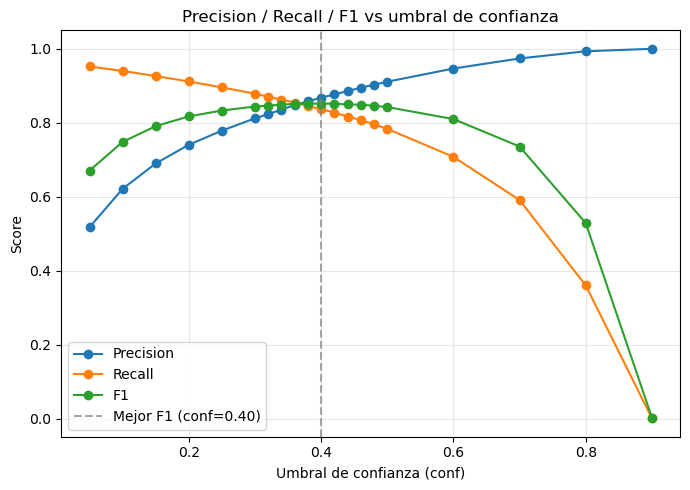

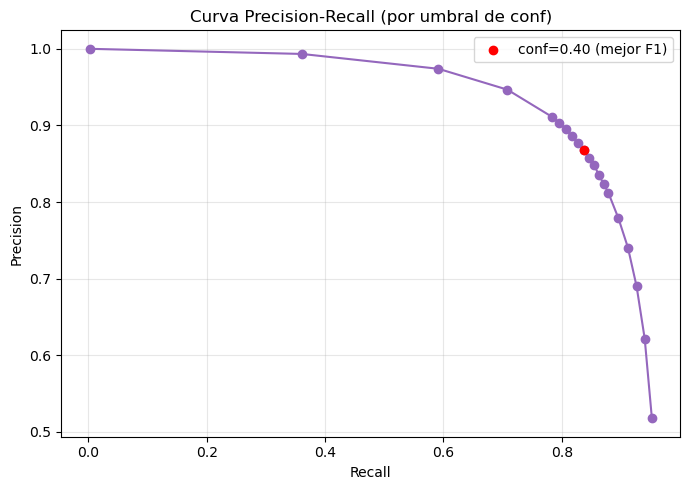

Punto de mejor balance (máximo F1): conf=0.40  (precision=0.868, recall=0.837, f1=0.852)


In [8]:
confs      = [r["conf"] for r in pr_sweep_results]
precisions = [r["precision"] for r in pr_sweep_results]
recalls    = [r["recall"] for r in pr_sweep_results]
f1s        = [r["f1"] for r in pr_sweep_results]

best_idx = max(range(len(f1s)), key=lambda i: f1s[i])
best_conf = confs[best_idx]

# Precision, Recall y F1 en función del umbral de confianza
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(confs, precisions, marker="o", label="Precision")
ax1.plot(confs, recalls, marker="o", label="Recall")
ax1.plot(confs, f1s, marker="o", label="F1")
ax1.axvline(best_conf, color="gray", linestyle="--", alpha=0.7,
            label=f"Mejor F1 (conf={best_conf:.2f})")
ax1.set_xlabel("Umbral de confianza (conf)")
ax1.set_ylabel("Score")
ax1.set_title("Precision / Recall / F1 vs umbral de confianza")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
fig1.savefig("precision_recall_f1_vs_conf.pdf")
plt.show()

# Curva Precision-Recall propiamente dicha
fig2, ax2 = plt.subplots(figsize=(7, 5))
order = sorted(range(len(confs)), key=lambda i: recalls[i])
ax2.plot([recalls[i] for i in order], [precisions[i] for i in order], marker="o", color="tab:purple")
ax2.scatter([recalls[best_idx]], [precisions[best_idx]], color="red", zorder=5,
            label=f"conf={best_conf:.2f} (mejor F1)")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Curva Precision-Recall (por umbral de conf)")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
fig2.savefig("precision_recall_curve.pdf")
plt.show()

print(f"Punto de mejor balance (máximo F1): conf={best_conf:.2f}  "
      f"(precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f}, f1={f1s[best_idx]:.3f})")
